# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Preprocessing

In [16]:
# Load data
raw = pd.read_csv('../data/checker_timestamp.csv', parse_dates=['timestamp'])
raw.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [17]:
# Extract date and hour
raw['date'] = raw['timestamp'].dt.date
raw['hour'] = raw['timestamp'].dt.hour
raw['dayofweek'] = raw['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday

# Count commits before midday (am) and after midday (pm) per day
raw['am'] = (raw['hour'] < 12).astype(int)
raw['pm'] = (raw['hour'] >= 12).astype(int)

# Group by date
df = raw.groupby('date').agg(
    am=('am', 'sum'),
    pm=('pm', 'sum'),
    dayofweek=('dayofweek', 'first')
).reset_index()

# Create target column
df['target'] = df['dayofweek'].apply(
    lambda x: 'weekend' if x >= 5 else 'working_day'
)

df = df[['date', 'am', 'pm', 'target']]
df.head()

,date,am,pm,target
0,2020-04-17,21,2,working_day
1,2020-04-18,1,68,weekend
2,2020-04-19,18,15,weekend
3,2020-04-20,2,23,working_day
4,2020-04-21,0,25,working_day


## 2. Exploratory analysis

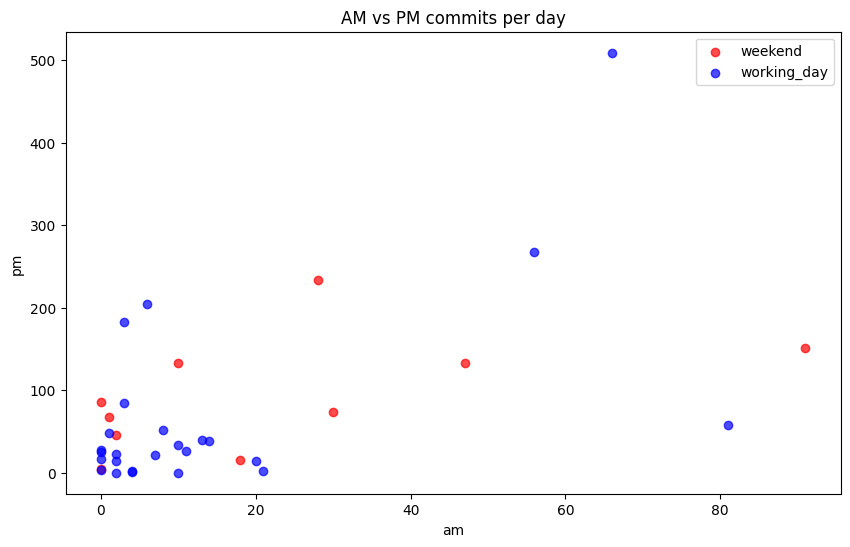

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'working_day': 'blue', 'weekend': 'red'}
for target, group in df.groupby('target'):
    ax.scatter(group['am'], group['pm'], 
               label=target, color=colors[target], alpha=0.7)

ax.set_xlabel('am')
ax.set_ylabel('pm')
ax.set_title('AM vs PM commits per day')
ax.legend()
plt.show()

no, it is not easy

## 3. Logistic regression

In [19]:
X = df[['am', 'pm']].values
y = df['target'].values

model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X, y)

df['predict'] = model.predict(X)
df.head()

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend
1,2020-04-18,1,68,weekend,working_day
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day


In [20]:
# Save to CSV
df.to_csv('../data/am_pm.csv', index=False)
print('Saved am_pm.csv')

Saved am_pm.csv


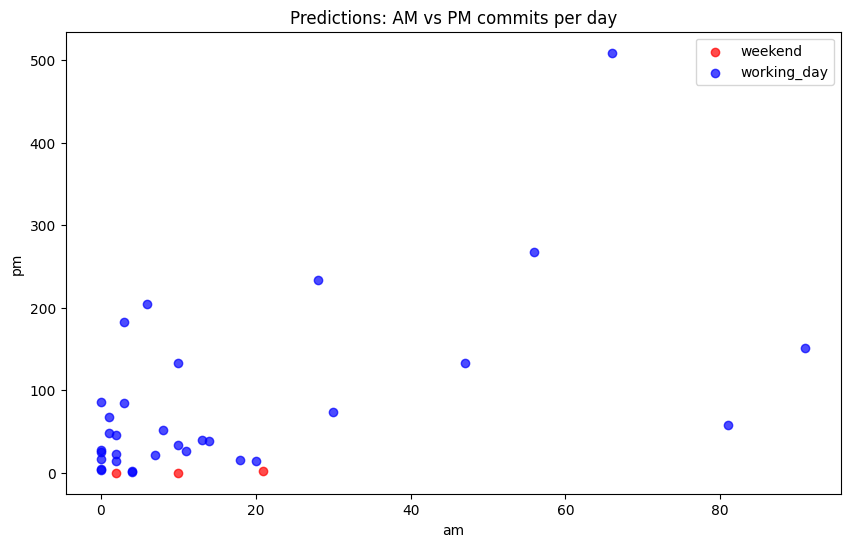

In [21]:
# Plot predictions
fig, ax = plt.subplots(figsize=(10, 6))

for target, group in df.groupby('predict'):
    ax.scatter(group['am'], group['pm'],
               label=target, color=colors[target], alpha=0.7)

ax.set_xlabel('am')
ax.set_ylabel('pm')
ax.set_title('Predictions: AM vs PM commits per day')
ax.legend()
plt.show()

no, it is not good

## 4. Evaluation

In [22]:
# Model accuracy
acc = accuracy_score(df['target'], df['predict'])
print(f'Model accuracy: {acc:.4f}')

# Naive accuracy - always predict most popular class
most_popular = df['target'].value_counts().index[0]
naive_acc = accuracy_score(df['target'], [most_popular] * len(df))
print(f'Naive accuracy (always predict {most_popular}): {naive_acc:.4f}')

Model accuracy: 0.6286
Naive accuracy (always predict working_day): 0.7143


no, it is not good